   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


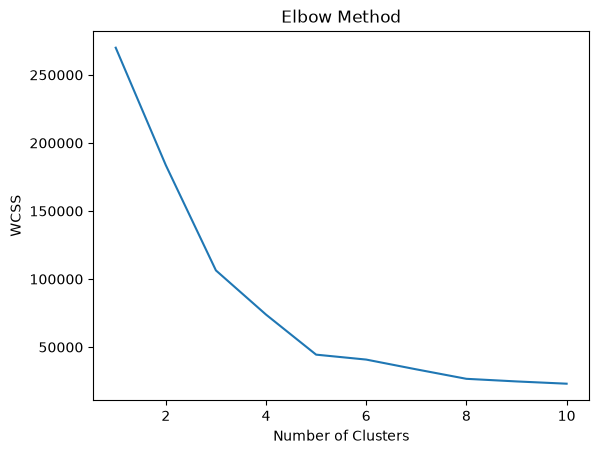

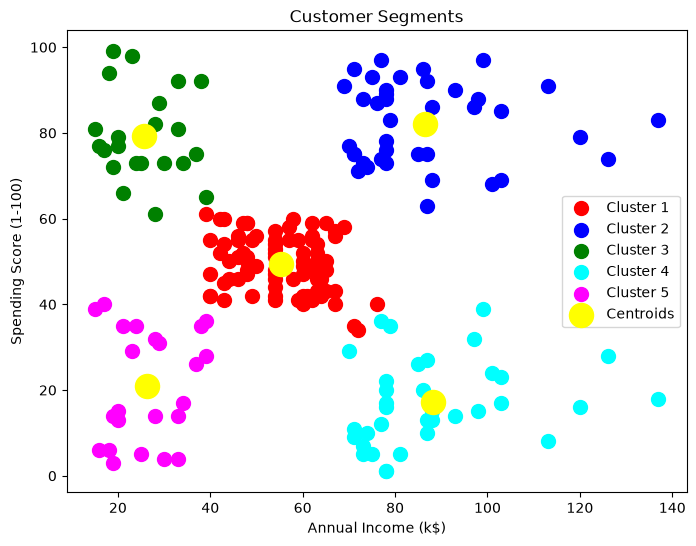

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = pd.read_csv("Mall_Customers.csv")
print(data.head())

x = data[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(x)

plt.figure(figsize=(8,6))

plt.scatter(x.iloc[y_kmeans==0,0], x.iloc[y_kmeans==0,1], s=100, c='red', label='Cluster 1')
plt.scatter(x.iloc[y_kmeans==1,0], x.iloc[y_kmeans==1,1], s=100, c='blue', label='Cluster 2')
plt.scatter(x.iloc[y_kmeans==2,0], x.iloc[y_kmeans==2,1], s=100, c='green', label='Cluster 3')
plt.scatter(x.iloc[y_kmeans==3,0], x.iloc[y_kmeans==3,1], s=100, c='cyan', label='Cluster 4')
plt.scatter(x.iloc[y_kmeans==4,0], x.iloc[y_kmeans==4,1], s=100, c='magenta', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=300,
            c='yellow',
            label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()